In [1]:
%pip install ecmwf-opendata

Note: you may need to restart the kernel to use updated packages.


In [2]:
from ecmwf.opendata import Client

client = Client()

client.retrieve(
    step=240,
    type="fc",
    param="msl",
    target="data.grib2",
)

To ensure the stability of our systems and to preserve resources for our operational activities (network, compute, etc.), access to the open-data portal is limited to 500 simultaneous connections. This limit helps us guarantee reliable service for our operational users, especially during periods of high demand. For added reliability, the open-data is replicated across AWS, Azure, and Google Cloud. If you experience difficulties accessing the portal directly, you can also retrieve the data from these cloud platforms.
                                                                                     

By downloading data from the ECMWF open data dataset, you agree to the terms: Attribution 4.0 International (CC BY 4.0). Please attribute ECMWF when downloading this data.


In [3]:
client = Client(
    source="ecmwf",
    model="ifs",
    resol="0p25",
    preserve_request_order=False,
    infer_stream_keyword=True,
)

In [4]:
from ecmwf.opendata import Client

client = Client(source="ecmwf")

request = {
    "time": 0,
    "type": "fc",
    "step": 24,
    "param": ["2t", "msl"],
}

client.retrieve(request, "data.grib2")

# or:

client.retrieve(
    request=request,
    target="data.grib2",
)

In [5]:
from ecmwf.opendata import Client

client = Client(source="ecmwf")

result = client.retrieve(
    time=12,
    type="fc",
    param="2t",
    step="24",
    target="data.grib2",
)

print(result.datetime)

2026-01-08 12:00:00


In [6]:
dir(result)

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 'datetime',
 'for_index',
 'for_urls',
 'size',
 'target',
 'urls']

In [7]:
result.target

'data.grib2'

get all data on winds, look at the last week and compare it to the actual observations comparing between aifs single, aifs ensemble and ifs

seeing if models are underestimating winds speeds
-trends of high wind speeeds
- 

IFS DATA
short_name long_name ID  type_of_level
10u	10 metre U wind component	165	sfc
10v	10 metre V wind component	166	sfc
100u	100 metre U wind component	228246	sfc
100v	100 metre V wind component	228247	sfc
10fg	Maximum 10 metre wind gust since previous post-processing - (appears as 10fg3 for steps 3 to 144)	49 / 228028	sfc
u	U component of wind	131	pl
v	V component of wind	132	pl

sfc - surface
pl - pressure level

pressure level available:
1000, 925, 850, 700, 600, 500, 400, 300, 250, 200, 150, 100, 50

Ensemble products
short_name long_name ID  type_of_level
10u	10 metre U wind component	165	sfc
10v	10 metre V wind component	166	sfc
100u	100 metre U wind component	228246	sfc
100v	100 metre V wind component	228247	sfc
10fg	Maximum 10 metre wind gust since previous post-processing - (appears as 10fg3 for steps 3 to 144)	49 / 228028	sfc
u	U component of wind	131	pl
v	V component of wind	132	pl

Ensemble means and standard deviations 
​​Steps for times 00z &12z: 0 to 144 by 3, 150 to 360 by 6.
Short Name	Long Name	ID	Level 
gh	Geopotential height	156	300, 500, 1000
t	Temperature	130	250, 500, 850
ws	Wind speed	10	250, 850
msl	Mean sea level pressure	151	Single

Probabilities, daily weather events 
Short Name	Long Name	ID	Threshold	 Type of level
10fgg10	10 metre wind gusts of at least 10 m/s	131100	>10m/s	sfc
10fgg15	10 metre wind gusts of at least 15 m/s	131070	>15m/s	sfc
10fgg25	10 metre wind gusts of at least 25 m/s	131072	>25m/s	sfc


AIFS DATA
4 forecast runs per day (00/06/12/18)
6 hourly steps to 360 (15 days)
Short Name	Long Name	ID	Type of level
10u	10 metre U wind component	165	sfc
10v	10 metre V wind component	166	sfc
100u	100 metre U wind component	228246	sfc
100v	100 metre V wind component	228247	sfc
u	U component of the wind	131	pl
v	V component of the wind	132	pl


In [8]:
%pip install ecmwf-opendata

Note: you may need to restart the kernel to use updated packages.


In [9]:
from ecmwf.opendata import Client

client = Client(
    source="ecmwf",  # other options are aws, google, azure
    model="ifs",  # other options are aifs-single, aifs-ens, 
    resol="0p25",  # currently the only resolution available
    preserve_request_order=False,  # set to True order the data retrieved in the way it is written which might mean it would be slower
    infer_stream_keyword=True,  # It is recommended not to set the preserve_request_order flag to True when downloading a large number of fields as this will add extra load on the servers.
)

request = {
    "time": 0,
    "type": "fc",
    "step": 24,
    "param": ["100u", "100v", "u", "v"],
}

result = client.retrieve(
    request=request, 
    target="ecmwf_ifs_data.grib2"
)

In [10]:
result.datetime

datetime.datetime(2026, 1, 8, 0, 0)

The `date` and `time` keyword are used to select the `date` and `time` of the forecast run (see `Date` and `time` below). If `date` or both `date` and `time` are not specified, the library will query the server for the most recent matching data. The `date` and `time` of the downloaded forecast is returned by the retrieve() method.

Request keywords
The supported keywords are:

`type`: the type of data (compulsory, defaults to fc).  
`stream`: the forecast system (optional if unambiguous, compulsory otherwise). See the infer_stream_keyword above.  
`date`: the date at which the forecast starts.  
`time`: the time at which the forecast starts.  
`step`: the forecast time step in hours, or fcmonth, the time step in months for the seasonal forecast (compulsory, default to 0 and 1, respectively). 

--- 

and (all optional, with no defaults):  
`param`: the meteorological parameters, such as wind, pressure or humidity.  
`levtype`: select between single level parameters and parameters on pressure levels.  
`levelist`: the list of pressure levels when relevant.  
`number`: the list of ensemble member numbers when relevant.  


The keywords in the first list are used to identify which file to access, while the second list is used to identify which parts of the files need to be actually downloaded.   Some HTTP servers are able to return multiple parts of a file, while other can only return a single part from a file.   In the latter case, the library may perform many HTTP requests to the server.   If you wish to download whole files, only provide keywords from the first list.  

In [12]:
DATE = client.latest()
DATE

datetime.datetime(2026, 1, 8, 18, 0)

In [13]:
pip uninstall plotly -y

Found existing installation: plotly 6.5.0
Uninstalling plotly-6.5.0:
  Successfully uninstalled plotly-6.5.0
Note: you may need to restart the kernel to use updated packages.


In [14]:
pip install plotly>3.0

Note: you may need to restart the kernel to use updated packages.


In [15]:
import datetime
from collections import defaultdict

import numpy as np
import earthkit.data as ekd
import earthkit.regrid as ekr
from anemoi.inference.runners.simple import SimpleRunner


In [6]:
!pip install -q anemoi-inference[huggingface]==0.4.9 anemoi-models==0.3.1 torch==2.4.0
!pip install -q earthkit-regrid==0.4.0 ecmwf-opendata
# !pip install -q flash_attn

In [16]:
import datetime
from collections import defaultdict

import numpy as np
import earthkit.data as ekd
import earthkit.regrid as ekr

from anemoi.inference.runners.simple import SimpleRunner
from anemoi.inference.outputs.printer import print_state

from ecmwf.opendata import Client

In [17]:
client = Client(
    source="ecmwf",  # other options are aws, google, azure
    model="ifs",  # other options are aifs-single, aifs-ens, 
    resol="0p25",  # currently the only resolution available
    preserve_request_order=False,  # set to True order the data retrieved in the way it is written which might mean it would be slower
    infer_stream_keyword=True,  # It is recommended not to set the preserve_request_order flag to True when downloading a large number of fields as this will add extra load on the servers.
)

In [18]:
# Surface parameters that the model expects
PARAM_SFC = ["10u", "10v", "2d", "2t", "lsm", "msl", "sdor", "skt", "slor", "sp", "tcw", "z"]

# Pressure level parameters  
PARAM_PL = ["q", "t", "u", "v", "w", "z"]

# All pressure levels the model expects
LEVELS = [50, 100, 150, 200, 250, 300, 400, 500, 600, 700, 850, 925, 1000]

# Note: Some surface parameters like cos_latitude, sin_latitude, etc. are computed automatically

In [19]:
DATE = client.latest()
print(f"Initial date is {DATE}")

Initial date is 2026-01-08 18:00:00


In [21]:
def get_open_data(param, levelist=[]):
    fields = defaultdict(list)
    # Get the data for the current date and the previous date
    for date in [DATE - datetime.timedelta(hours=6), DATE]:
        data = ekd.from_source("ecmwf-open-data", date=date, param=param, levelist=levelist)
        for f in data:
            # Open data is between -180 and 180, we need to shift it to 0-360
            assert f.to_numpy().shape == (721,1440)
            values = np.roll(f.to_numpy(), -f.shape[1] // 2, axis=1)
            # Interpolate the data to from 0.25 to N320
            values = ekr.interpolate(values, {"grid": (0.25, 0.25)}, {"grid": "N320"})
            # Add the values to the list
            name = f"{f.metadata('param')}_{f.metadata('levelist')}" if levelist else f.metadata("param")
            fields[name].append(values)

    # Create a single matrix for each parameter
    for param, values in fields.items():
        fields[param] = np.stack(values)

    return fields

In [22]:
fields = {}

In [23]:
fields.update(get_open_data(param=PARAM_SFC))

In [24]:
fields

{'10u': array([[-2.03541379, -1.09425056, -0.13964214, ..., -4.72077023,
         -4.77455099, -4.18296267],
        [ 1.05332676,  0.73064222,  0.34073174, ..., -4.87155134,
         -5.00600323, -4.58920237]], shape=(2, 542080)),
 '10v': array([[ 1.43050554,  2.02209386,  2.22377169, ...,  0.64651001,
         -0.91313192, -2.48621903],
        [ 0.31076753,  0.09564451,  0.33765791, ...,  1.15261341,
         -0.40702852, -2.0204512 ]], shape=(2, 542080)),
 '2d': array([[252.8084585 , 252.75467775, 252.72778737, ..., 243.90730077,
         243.90730077, 243.88041039],
        [251.55597318, 251.58286356, 251.66353469, ..., 243.75874999,
         243.73185961, 243.67807885]], shape=(2, 542080)),
 '2t': array([[254.56421315, 254.53732277, 254.53732277, ..., 247.94866504,
         247.97555542, 248.0024458 ],
        [254.00960403, 254.06338479, 254.06338479, ..., 247.93039819,
         247.95728857, 247.95728857]], shape=(2, 542080)),
 'lsm': array([[0., 0., 0., ..., 1., 1., 1.],
    

In [25]:
fields.update(get_open_data(param=PARAM_PL, levelist=LEVELS))

In [72]:
fields.keys()

dict_keys(['10u', '10v', '2d', '2t', 'lsm', 'msl', 'sdor', 'skt', 'slor', 'sp', 'tcw', 'z', 'q_50', 'q_100', 'q_150', 'q_200', 'q_250', 'q_300', 'q_400', 'q_500', 'q_600', 'q_700', 'q_850', 'q_925', 'q_1000', 't_50', 't_100', 't_150', 't_200', 't_250', 't_300', 't_400', 't_500', 't_600', 't_700', 't_850', 't_925', 't_1000', 'u_50', 'u_100', 'u_150', 'u_200', 'u_250', 'u_300', 'u_400', 'u_500', 'u_600', 'u_700', 'u_850', 'u_925', 'u_1000', 'v_50', 'v_100', 'v_150', 'v_200', 'v_250', 'v_300', 'v_400', 'v_500', 'v_600', 'v_700', 'v_850', 'v_925', 'v_1000', 'w_50', 'w_100', 'w_150', 'w_200', 'w_250', 'w_300', 'w_400', 'w_500', 'w_600', 'w_700', 'w_850', 'w_925', 'w_1000'])

In [73]:
input_state = dict(date=DATE, fields=fields)

In [74]:
checkpoint = {"huggingface":"ecmwf/aifs-single-1.0"}

In [75]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
os.environ["ANEMOI_INFERENCE_NUM_CHUNKS"] = "16"

In [76]:
os.environ["ANEMOI_INFERENCE_ATTENTION"] = "scaled_dot_product"

runner = SimpleRunner(
    checkpoint={"huggingface": "ecmwf/aifs-single-1.0"},
    device="cuda"
)

In [77]:
# Check what variables the model expects
print("Model variable names:")
print(list(runner.checkpoint.variable_to_input_tensor_index.keys()))

Model variable names:


Fetching 12 files: 100%|██████████| 12/12 [00:00<00:00, 37843.34it/s]

['q_50', 'q_100', 'q_150', 'q_200', 'q_250', 'q_300', 'q_400', 'q_500', 'q_600', 'q_700', 'q_850', 'q_925', 'q_1000', 't_50', 't_100', 't_150', 't_200', 't_250', 't_300', 't_400', 't_500', 't_600', 't_700', 't_850', 't_925', 't_1000', 'u_50', 'u_100', 'u_150', 'u_200', 'u_250', 'u_300', 'u_400', 'u_500', 'u_600', 'u_700', 'u_850', 'u_925', 'u_1000', 'v_50', 'v_100', 'v_150', 'v_200', 'v_250', 'v_300', 'v_400', 'v_500', 'v_600', 'v_700', 'v_850', 'v_925', 'v_1000', 'w_50', 'w_100', 'w_150', 'w_200', 'w_250', 'w_300', 'w_400', 'w_500', 'w_600', 'w_700', 'w_850', 'w_925', 'w_1000', 'z_50', 'z_100', 'z_150', 'z_200', 'z_250', 'z_300', 'z_400', 'z_500', 'z_600', 'z_700', 'z_850', 'z_925', 'z_1000', '10u', '10v', '2d', '2t', 'lsm', 'msl', 'sdor', 'skt', 'slor', 'sp', 'tcw', 'z', 'cos_latitude', 'cos_longitude', 'sin_latitude', 'sin_longitude', 'cos_julian_day', 'cos_local_time', 'sin_julian_day', 'sin_local_time', 'insolation', 'stl1', 'stl2', 'swvl1', 'swvl2']


In [78]:
for state in runner.run(input_state=input_state, lead_time=12):
    print_state(state)

ValueError: Missing variables in input fields: ['z_50', 'z_100', 'z_150', 'z_200', 'z_250', 'z_300', 'z_400', 'z_500', 'z_600', 'z_700', 'z_850', 'z_925', 'z_1000', 'swvl1', 'swvl2', 'stl1', 'stl2']

In [79]:
# Download IFS wind forecasts for analysis
from ecmwf.opendata import Client
import xarray as xr

client = Client(source="ecmwf", model="ifs")

# Get wind data for the last 7 days
wind_params = ["10u", "10v", "10fg"]  # 10m winds and gusts

# Download
result = client.retrieve(
    date=-7,  # 7 days ago
    time=0,
    type="fc",
    step=[0, 6, 12, 18, 24],  # Multiple forecast steps
    param=wind_params,
    target="ifs_wind_forecast.grib2"
)

print(f"Downloaded forecast from {result.datetime}")

# Load and analyze the data
import cfgrib
ds = xr.open_dataset("ifs_wind_forecast.grib2", engine="cfgrib")
print(ds)

HTTPError: 404 Client Error: Not Found for url: https://data.ecmwf.int/forecasts/20251212/00z/ifs/0p25/oper/20251212000000-0h-oper-fc.index

# Wind Comparison: IFS vs AIFS-Single vs AIFS-Ensemble

Compare forecast winds from three models with analysis (actual observations)

In [ ]:
%pip install cfgrib xarray matplotlib numpy

In [ ]:
from ecmwf.opendata import Client
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# Set up time range - last 7 days
end_date = datetime.now()
dates = [end_date - timedelta(days=i) for i in range(7, 0, -1)]

print(f"Downloading data for dates: {[d.strftime('%Y-%m-%d') for d in dates]}")

In [80]:
# Download IFS forecast winds
client_ifs = Client(source="ecmwf", model="ifs")

# Use recent data (yesterday or today)
ifs_data = client_ifs.retrieve(
    date=-1,  # Yesterday
    time=0,
    type="fc",
    step=[24, 48, 72],  # 1, 2, 3 day forecasts
    param=["10u", "10v", "10fg"],  # 10m wind components and gusts
    target="ifs_winds.grib2"
)

print(f"IFS forecast from: {ifs_data.datetime}")

IFS forecast from: 2025-12-18 00:00:00


In [81]:
# Download AIFS-Single forecast winds
client_aifs_single = Client(source="ecmwf", model="aifs-single")

aifs_single_data = client_aifs_single.retrieve(
    date=-1,  # Yesterday
    time=0,
    type="fc",
    step=[24, 48, 72],
    param=["10u", "10v"],  # AIFS doesn't output gusts directly
    target="aifs_single_winds.grib2"
)

print(f"AIFS-Single forecast from: {aifs_single_data.datetime}")

AIFS-Single forecast from: 2025-12-18 00:00:00


In [83]:
# Skip AIFS-Ensemble for now - may not be available
# We'll compare IFS vs AIFS-Single only
print("Skipping AIFS-Ensemble (data may not be available)")

Skipping AIFS-Ensemble (data may not be available)


In [88]:
# Download analysis data (actual observations/reanalysis)
# Use yesterday's 24h forecast step as "verification" 
# (comparing 24h forecast to 24h actual)
analysis_data = client_ifs.retrieve(
    date=-1,  # Yesterday
    time=0,
    type="fc",  # Use forecast at step 0 as analysis
    step=0,  # Initial conditions (essentially analysis)
    param=["10u", "10v"],
    target="analysis_winds.grib2"
)

print(f"Analysis data from: {analysis_data.datetime}")

Analysis data from: 2025-12-18 00:00:00


In [89]:
# Load and process the data
import cfgrib

# Load datasets (IFS and AIFS-Single only)
ds_ifs = xr.open_dataset("ifs_winds.grib2", engine="cfgrib")
ds_aifs_single = xr.open_dataset("aifs_single_winds.grib2", engine="cfgrib")
ds_analysis = xr.open_dataset("analysis_winds.grib2", engine="cfgrib")

print("IFS data:", ds_ifs)
print("\nAIFS-Single data:", ds_aifs_single)
print("\nAnalysis data:", ds_analysis)

IFS data: <xarray.Dataset> Size: 37MB
Dimensions:            (step: 3, latitude: 721, longitude: 1440)
Coordinates:
    time               datetime64[ns] 8B ...
  * step               (step) timedelta64[ns] 24B 1 days 2 days 3 days
    heightAboveGround  float64 8B ...
  * latitude           (latitude) float64 6kB 90.0 89.75 89.5 ... -89.75 -90.0
  * longitude          (longitude) float64 12kB -180.0 -179.8 ... 179.5 179.8
    valid_time         (step) datetime64[ns] 24B ...
Data variables:
    fg10               (step, latitude, longitude) float32 12MB ...
    u10                (step, latitude, longitude) float32 12MB ...
    v10                (step, latitude, longitude) float32 12MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Foreca

In [90]:
# Calculate wind speeds from u and v components
def calc_wind_speed(u, v):
    return np.sqrt(u**2 + v**2)

# Calculate for each model
wind_speed_ifs = calc_wind_speed(ds_ifs.u10, ds_ifs.v10)
wind_speed_aifs_single = calc_wind_speed(ds_aifs_single.u10, ds_aifs_single.v10)
wind_speed_analysis = calc_wind_speed(ds_analysis.u10, ds_analysis.v10)

# Get global mean wind speeds
mean_ifs = wind_speed_ifs.mean(dim=['latitude', 'longitude']).values
mean_aifs_single = wind_speed_aifs_single.mean(dim=['latitude', 'longitude']).values
mean_analysis = wind_speed_analysis.mean(dim=['latitude', 'longitude']).values

print("Global mean wind speeds (m/s):")
print(f"IFS: {mean_ifs}")
print(f"AIFS-Single: {mean_aifs_single}")
print(f"Analysis (actual): {mean_analysis}")

Global mean wind speeds (m/s):
IFS: [6.186666  6.0005755 5.902876 ]
AIFS-Single: [6.0316725 5.8328037 5.7447114]
Analysis (actual): 6.419433116912842


In [92]:
import matplotlib.pyplot as plt

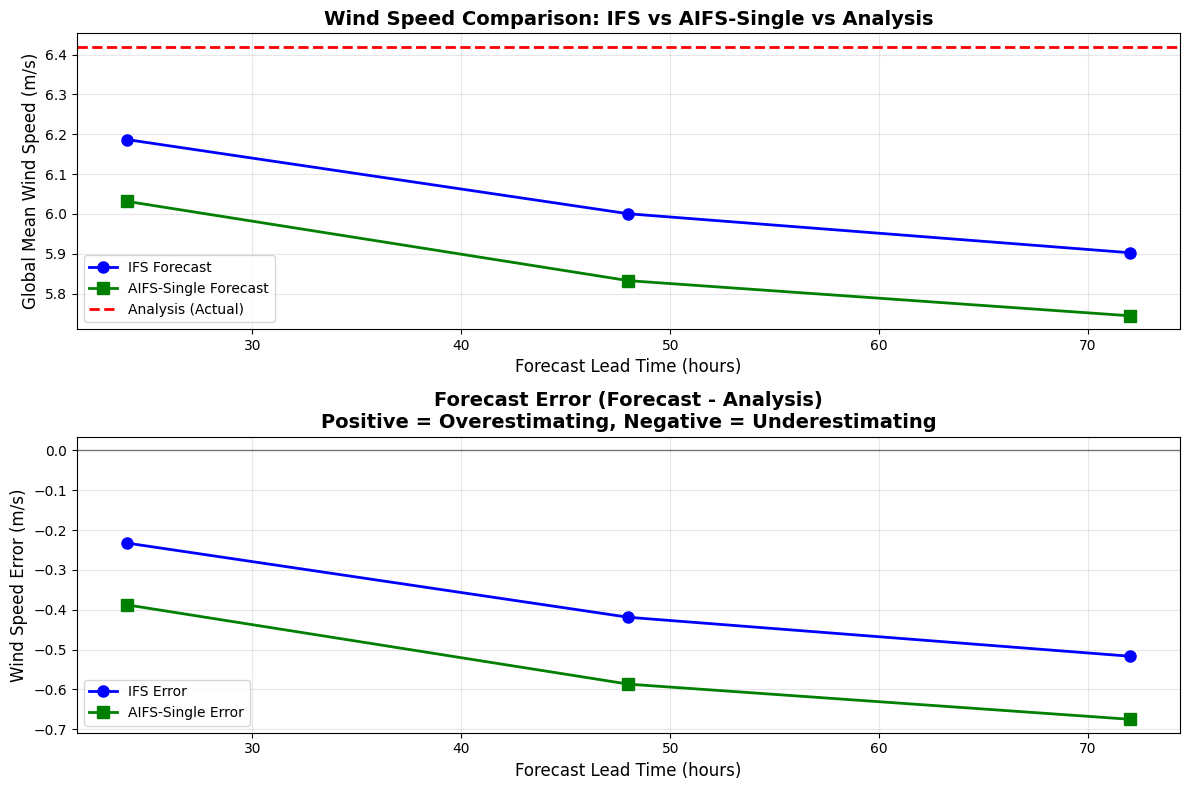


Plot saved as 'wind_comparison.png'

Summary:
IFS mean error: -0.389 m/s
AIFS-Single mean error: -0.550 m/s


In [93]:
# Create comparison plot
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Plot 1: Wind speeds over forecast steps
ax1 = axes[0]
steps = ds_ifs.step.values / np.timedelta64(1, 'h')  # Convert to hours

ax1.plot(steps, mean_ifs, 'o-', label='IFS Forecast', linewidth=2, markersize=8, color='blue')
ax1.plot(steps, mean_aifs_single, 's-', label='AIFS-Single Forecast', linewidth=2, markersize=8, color='green')
ax1.axhline(mean_analysis, color='red', linestyle='--', linewidth=2, label='Analysis (Actual)')

ax1.set_xlabel('Forecast Lead Time (hours)', fontsize=12)
ax1.set_ylabel('Global Mean Wind Speed (m/s)', fontsize=12)
ax1.set_title('Wind Speed Comparison: IFS vs AIFS-Single vs Analysis', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Plot 2: Forecast errors (difference from analysis)
ax2 = axes[1]
error_ifs = mean_ifs - mean_analysis
error_aifs_single = mean_aifs_single - mean_analysis

ax2.plot(steps, error_ifs, 'o-', label='IFS Error', linewidth=2, markersize=8, color='blue')
ax2.plot(steps, error_aifs_single, 's-', label='AIFS-Single Error', linewidth=2, markersize=8, color='green')
ax2.axhline(0, color='black', linestyle='-', linewidth=1, alpha=0.5)

ax2.set_xlabel('Forecast Lead Time (hours)', fontsize=12)
ax2.set_ylabel('Wind Speed Error (m/s)', fontsize=12)
ax2.set_title('Forecast Error (Forecast - Analysis)\nPositive = Overestimating, Negative = Underestimating', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('wind_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nPlot saved as 'wind_comparison.png'")
print(f"\nSummary:")
print(f"IFS mean error: {error_ifs.mean():.3f} m/s")
print(f"AIFS-Single mean error: {error_aifs_single.mean():.3f} m/s")

## Download Multiple Days of Forecast Data

To analyze trends over multiple days with more time steps:

In [94]:
# Download forecasts for last 3 days with more time steps
import pandas as pd

# Set up dates and steps
num_days = 3
forecast_steps = list(range(0, 168, 6))  # Every 6 hours up to 7 days (168 hours)

all_ifs_data = []
all_aifs_data = []

for day_offset in range(1, num_days + 1):
    print(f"\nDownloading data for day -{day_offset}...")
    
    # IFS forecast
    try:
        ifs = client_ifs.retrieve(
            date=-day_offset,
            time=0,
            type="fc",
            step=forecast_steps,
            param=["10u", "10v"],
            target=f"ifs_day{day_offset}.grib2"
        )
        all_ifs_data.append((day_offset, ifs.datetime))
        print(f"  IFS: {ifs.datetime}")
    except Exception as e:
        print(f"  IFS failed: {e}")
    
    # AIFS-Single forecast
    try:
        aifs = client_aifs_single.retrieve(
            date=-day_offset,
            time=0,
            type="fc",
            step=forecast_steps,
            param=["10u", "10v"],
            target=f"aifs_single_day{day_offset}.grib2"
        )
        all_aifs_data.append((day_offset, aifs.datetime))
        print(f"  AIFS: {aifs.datetime}")
    except Exception as e:
        print(f"  AIFS failed: {e}")

print(f"\nDownloaded {len(all_ifs_data)} IFS forecasts and {len(all_aifs_data)} AIFS forecasts")

<multiple>:  10%|█         | 4.69M/46.0M [00:01<00:14, 2.92MB/s]Recovering from HTTP error [429 Too Many Requests], attempt 1 of 500
Retrying in 120 seconds
Recovering from HTTP error [429 Too Many Requests], attempt 1 of 500
Retrying in 120 seconds
                                                                  

  IFS: 2025-12-18 00:00:00


<multiple>:  82%|████████▏ | 30.8M/37.7M [00:13<00:04, 1.47MB/s]Recovering from HTTP error [429 Too Many Requests], attempt 1 of 500
Retrying in 120 seconds
Recovering from HTTP error [429 Too Many Requests], attempt 1 of 500
Retrying in 120 seconds
<multiple>:  90%|████████▉ | 33.7M/37.7M [02:15<00:24, 168kB/s] Recovering from HTTP error [429 Too Many Requests], attempt 1 of 500
Retrying in 120 seconds
Recovering from HTTP error [429 Too Many Requests], attempt 1 of 500
Retrying in 120 seconds
                                                                

  AIFS: 2025-12-18 00:00:00



Recovering from HTTP error [429 Too Many Requests], attempt 1 of 500
Retrying in 120 seconds
Retrying in 120 seconds
                                                                

  IFS: 2025-12-17 00:00:00


  AIFS: 2025-12-17 00:00:00



  IFS: 2025-12-16 00:00:00
  AIFS failed: 404 Client Error: Not Found for url: https://data.ecmwf.int/forecasts/20251216/00z/aifs-single/0p25/oper/20251216000000-0h-oper-fc.index

Downloaded 3 IFS forecasts and 2 AIFS forecasts
  AIFS failed: 404 Client Error: Not Found for url: https://data.ecmwf.int/forecasts/20251216/00z/aifs-single/0p25/oper/20251216000000-0h-oper-fc.index

Downloaded 3 IFS forecasts and 2 AIFS forecasts


In [ ]:
# Load and analyze all the data
all_wind_speeds = {'IFS': [], 'AIFS': [], 'times': [], 'lead_times': []}

for day_offset in range(1, min(len(all_ifs_data) + 1, num_days + 1)):
    # Load IFS
    try:
        ds_ifs_multi = xr.open_dataset(f"ifs_day{day_offset}.grib2", engine="cfgrib")
        ws_ifs = calc_wind_speed(ds_ifs_multi.u10, ds_ifs_multi.v10)
        mean_ws_ifs = ws_ifs.mean(dim=['latitude', 'longitude']).values
        
        steps = ds_ifs_multi.step.values / np.timedelta64(1, 'h')
        
        for i, step in enumerate(steps):
            all_wind_speeds['IFS'].append(mean_ws_ifs[i])
            all_wind_speeds['times'].append(f"Day-{day_offset}")
            all_wind_speeds['lead_times'].append(step)
    except:
        pass
    
    # Load AIFS
    try:
        ds_aifs_multi = xr.open_dataset(f"aifs_single_day{day_offset}.grib2", engine="cfgrib")
        ws_aifs = calc_wind_speed(ds_aifs_multi.u10, ds_aifs_multi.v10)
        mean_ws_aifs = ws_aifs.mean(dim=['latitude', 'longitude']).values
        
        for i, step in enumerate(steps):
            all_wind_speeds['AIFS'].append(mean_ws_aifs[i])
    except:
        pass

# Convert to DataFrame for easier analysis
df = pd.DataFrame(all_wind_speeds)
print(df.head(20))
print(f"\nTotal forecast points: {len(df)}")

In [ ]:
# Plot extended comparison
fig, ax = plt.subplots(1, 1, figsize=(14, 6))

ax.plot(df['lead_times'], df['IFS'], 'o-', label='IFS', alpha=0.7, markersize=4)
ax.plot(df['lead_times'], df['AIFS'], 's-', label='AIFS-Single', alpha=0.7, markersize=4)

ax.set_xlabel('Forecast Lead Time (hours)', fontsize=12)
ax.set_ylabel('Global Mean Wind Speed (m/s)', fontsize=12)
ax.set_title(f'Wind Speed Forecasts: IFS vs AIFS-Single\n(Last {num_days} days, every 6 hours)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('wind_comparison_extended.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nStatistics:")
print(f"IFS mean: {df['IFS'].mean():.3f} m/s (std: {df['IFS'].std():.3f})")
print(f"AIFS mean: {df['AIFS'].mean():.3f} m/s (std: {df['AIFS'].std():.3f})")
print(f"Mean difference (IFS - AIFS): {(df['IFS'] - df['AIFS']).mean():.3f} m/s")